# Week 7 (End to end Data Driven Project)

## Compare and Evaluate Learning Algorithms

In this tutorial, we will create an end-to-end framework using Machine Learning. We will be using
a dataset from the UCI repository, available Here. Through this tutorial, you will develop good
knowledge and understanding of the following key topics:

• Explore and prepare dataset for machine learning

• Train your model

• Train and Evaluate more than one model

• Compare results using ROC curve

• **(Optional)**: And deploying the solution using streamlit

**Resources**

• [Book on Machine Learning Hands-On Machine Learning with Scikit-Learn, Keras
and TensorFlow](https://www.oreilly.com/library/view/hands-on-machine-learning/9781492032632/)

• [Excellent read on data leakage which is a common problem in Machine Learning](https://machinelearningmastery.com/data-leakage-machine-learning/)

### 1.1 Problem

**Task:** The data is related with direct marketing campaigns (phone calls) of a Portuguese banking
institution. The classification goal is to predict if a client will subscribe a term deposit (variable y). Campaigns were based on phone calls. Often, more than one contact to the same client was required, in order to assess if the product (bank term deposit) would be (‘yes’) or not (‘no’) subscribed.

### 1.2 Data Availability

[Data is available at the UCI repository here](https://archive.ics.uci.edu/dataset/222/bank+marketing). The dataset contains information about bank clients such as age, job, marital status, has a house loan, and so on. Some of these features are numerical and others are categorical as we will see in the details below. The dataset also contains information about the calls made during the campaign, such as date and time, duration, and so on. The output feature (target variable) is y, which indicates if the client subscribed a term deposit? (binary:‘yes’,‘no’)

#### 1.2.1 Load and Explore the Data

In [2]:
import pandas as pd
import numpy as np
# for plottng
import matplotlib.pyplot as plt
import seaborn as sns
# note that ';' is used as the separator between columns (features)
df = pd.read_csv('bank-full.csv',sep=';')

In [3]:
# show few rows, columns and the class label
df[['age','job','education','y']].head()

,age,job,education,y
0,58,management,tertiary,no
1,44,technician,secondary,no
2,33,entrepreneur,secondary,no
3,47,blue-collar,unknown,no
4,33,unknown,unknown,no


In [4]:
# print the size of the dataset
print(f'The dataset has {df.shape[0]} rows, and {df.shape[1]} columns')

The dataset has 45211 rows, and 17 columns


Let's check the data types of the input features in the dataset using df.info() function. You can see below, that we have some features that are of numeric values while others are categorical (objects). By checking the dataset, you will notice that some of the categorical variables are text, while other just contain repetitive values.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


One more thing you can notice from the above outcome of the df.info() function, is that our
dataset has no missing values (e.g. check all non-null values above are equal to the number of
rows in the dataset). You can double check this fact as follows:
df.isnull().sum()

You can further check the type of attributes and the kind of values it contains by using the
df["x"].value_counts() as can be seen below

In [6]:
df['job'].value_counts()

job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64

One very useful function in the pandas is the `describe()` function, that show the summary
statistics of all numerical features in your dataset. Notice that the five summary numbers
discussed in the lecture are listed using this function:

In [ ]:
df.describe()

The values of min, max and mean are self explanatory and represent values of the corresponding
features. The std row represents the standard deviation, that measures how dispersed
the values are. The 25%, 50% and 75% represent the percentiles discussed in the
lecture. For example, 25% of the clients in the dataset are of age lower than 33 years, while
50% of the clients are of age lower than 39 years, and so on for other attributes.

Let's plot histogram of numerical values for our dataset. But first, lets create a list that represent numerical features as follows:

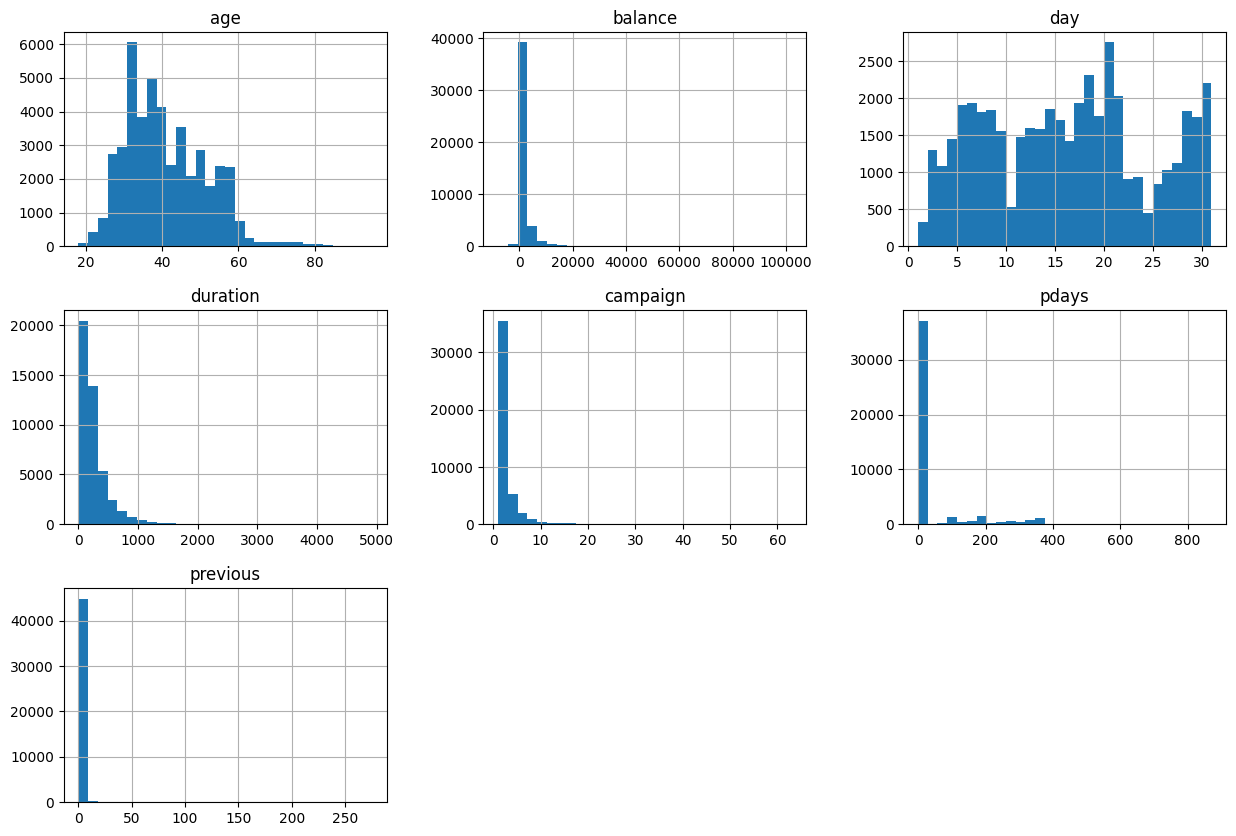

In [7]:
numerical_vals = ['age','balance','day','duration','campaign','pdays','previous']
# Manually selected the numerical values using information from previous functions.
df[numerical_vals].hist(bins=30,figsize=(15,10))
plt.show()

Two quick notes about the above histograms. First, notice that all numerical features in the
dataset shown in the above histogram vary in scales (e.g. age values range between 18 to 95,
while day ranges between 1 to 31). We need to handle this problem by putting all features
values within the same scale as will be discussed in the pre-processing section. The second
note, is that the data is not normally distributed (apart from the age) , and we have also to
transform it more into a normal distribution.


You can also use seaborn to produce various types of plots to gain more insight about the
dataset. Details about various types of plots and visualisations can be find [here library](https://seaborn.pydata.org/tutorial/distributions.html). Below is a plot for the age distribution with a density curve:

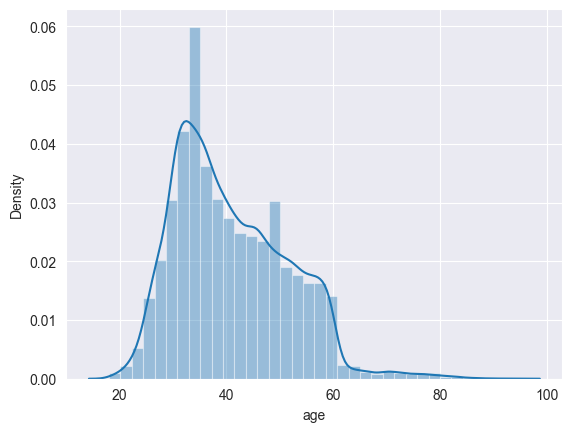

In [19]:
sns.set_style(style="darkgrid")
sns.histplot(
    df["age"], kde=True,
    bins=int(180/5),
    stat="density", kde_kws=dict(cut=3),
    alpha=.4, edgecolor=(1, 1, 1, .4),
)
plt.show()

Similarly, we can produce a separate histogram for durations as follows:

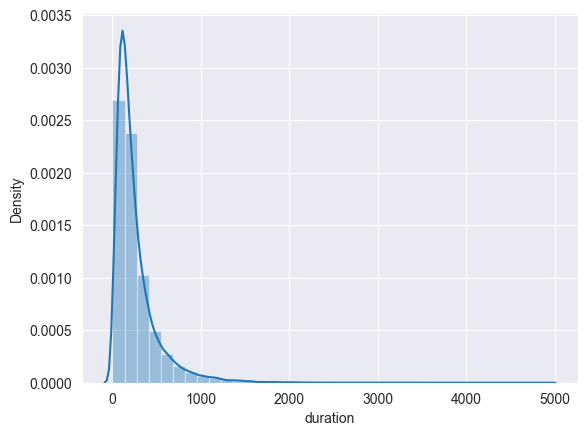

In [20]:
sns.histplot(
    df["duration"], kde=True,
    bins=int(180/5),
    stat="density", kde_kws=dict(cut=3),
    alpha=.4, edgecolor=(1, 1, 1, .4),
)
plt.show()

One thing, and as always should be explored is the class distribution. Recall, that we want to
predict the y value, in our dataset, this also represent the column called y, representing if a client subscribed a term deposit (‘yes’), or not (‘no’)?

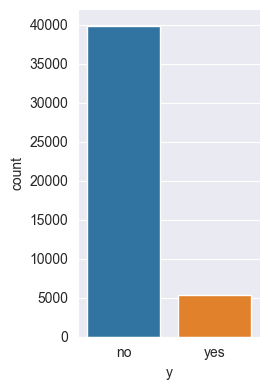

In [21]:
sns.catplot(x="y", hue="y",
data=df, kind="count",
height=4, aspect=.7)
plt.show()

The above diagram, shows clearly that the dataset is imbalanced. This is a problem for most machine
learning algorithms, as the algorithms tend to be biased toward the majority class instances
(in this case those who didn’t subscribe a term deposit). You can check the ratio of those who
subscribed "yes" versus the "no" as follows:

In [22]:
# number of records with 'yes' label
n_yes= df[df.y=='yes'].shape[0]
# number of records with 'non' label
n_no = df[df.y=='no'].shape[0]
# print percentage of both examples
print(f'There is {n_yes} examples with yes label, which is {round(n_yes/df.shape[0],2)*100}%')
print(f'There is {n_no} examples with no label, which is {round(n_no/df.shape[0],2)*100}%')

There is 5289 examples with yes label, which is 12.0%
There is 39922 examples with no label, which is 88.0%


Notice, that each visualisation we showed above, shed more light on the data, and will inform our
approach to pre-process and prepare the data, as will be shown later in this tutorial. You can also
check the class distribution according to a certain category. For instance, lets see how clients of
specific education background subscribed a deposit or not.

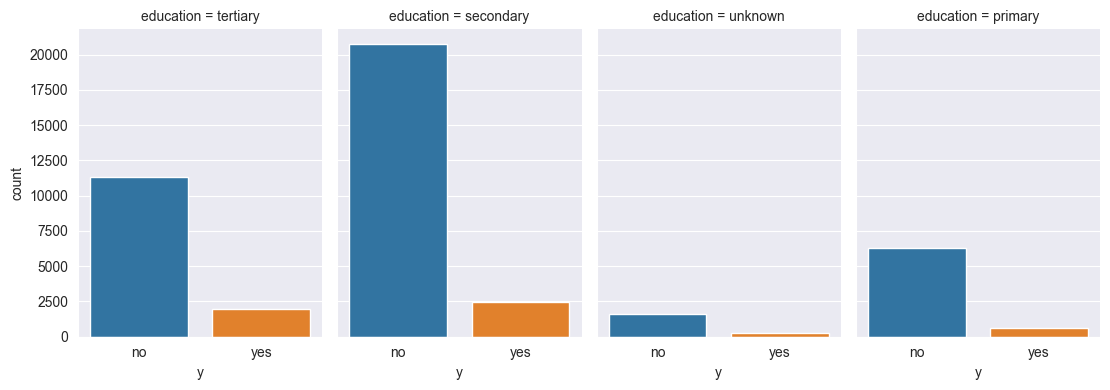

In [23]:
sns.catplot(x="y", hue="y",col='education',
data=df, kind="count",
height=4, aspect=.7)
plt.show()

Notice, that the diagram, below shows that non of the customers who defaulted, subscribed
a term deposit (as expected):

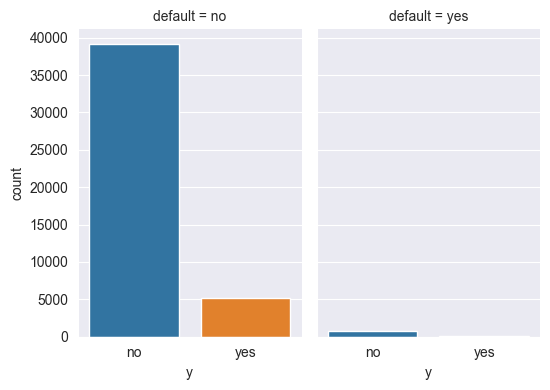

In [24]:
sns.catplot(x="y", hue="y",col='default',
data=df, kind="count",
height=4, aspect=.7)
plt.show()

We can also explore the distribution of class labels (y = yes/no) based on the type of contact
by the marketing campaign. Notice that the diagram showed that majority of those who
subscribed to term deposit were actually contacted by a mobile phone.

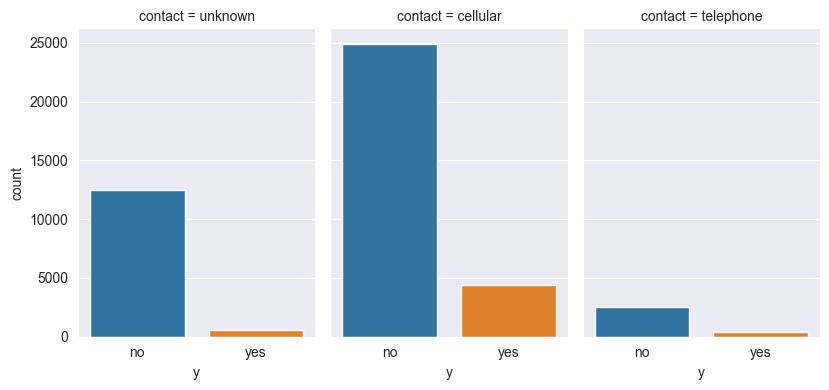

In [25]:
sns.catplot(x="y", hue="y",col='contact',
data=df, kind="count",
height=4, aspect=.7)
plt.show()

And of course, you can always explore the age distribution of customers and its association
with the subscription to a deposit or not?

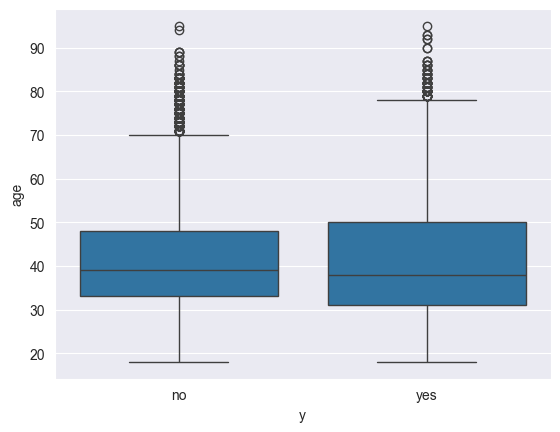

In [26]:
sns.boxplot(x="y", y="age", data=df)
plt.show()

Correlations: It is always good to explore correlations between features in your dataset. The
simplest way to do so, is to us the corr() function of the pandas DataFrame. Notice, that this
function only computes the correlation coefficient between numerical features.

In [29]:
corr_mat= df.corr(numeric_only = True)
corr_mat

,age,balance,day,duration,campaign,pdays,previous
age,1.000000,0.097783,-0.009120,-0.004648,0.004760,-0.023758,0.001288
balance,0.097783,1.000000,0.004503,0.021560,-0.014578,0.003435,0.016674
day,-0.009120,0.004503,1.000000,-0.030206,0.162490,-0.093044,-0.051710
duration,-0.004648,0.021560,-0.030206,1.000000,-0.084570,-0.001565,0.001203
campaign,0.004760,-0.014578,0.162490,-0.084570,1.000000,-0.088628,-0.032855
pdays,-0.023758,0.003435,-0.093044,-0.001565,-0.088628,1.000000,0.454820
previous,0.001288,0.016674,-0.051710,0.001203,-0.032855,0.454820,1.000000


Now, you can easily check how certain attributes correlates with the rest of attributes. Let's
look at the age attribute, and you will notice that it is not highly correlated with any of the
other features:

In [30]:
# age attribute
corr_mat['age'].sort_values(ascending=False)

age         1.000000
balance     0.097783
campaign    0.004760
previous    0.001288
duration   -0.004648
day        -0.009120
pdays      -0.023758
Name: age, dtype: float64

Similarly, you can explore other correlations. As discussed in previous weeks, correlations
values ranges between -1 and 1, and you should now be able to interpret these numbers. You
can also visually explore correlations using the pandas scatter matrix (as we did in previous
weeks, or the seaborn library):

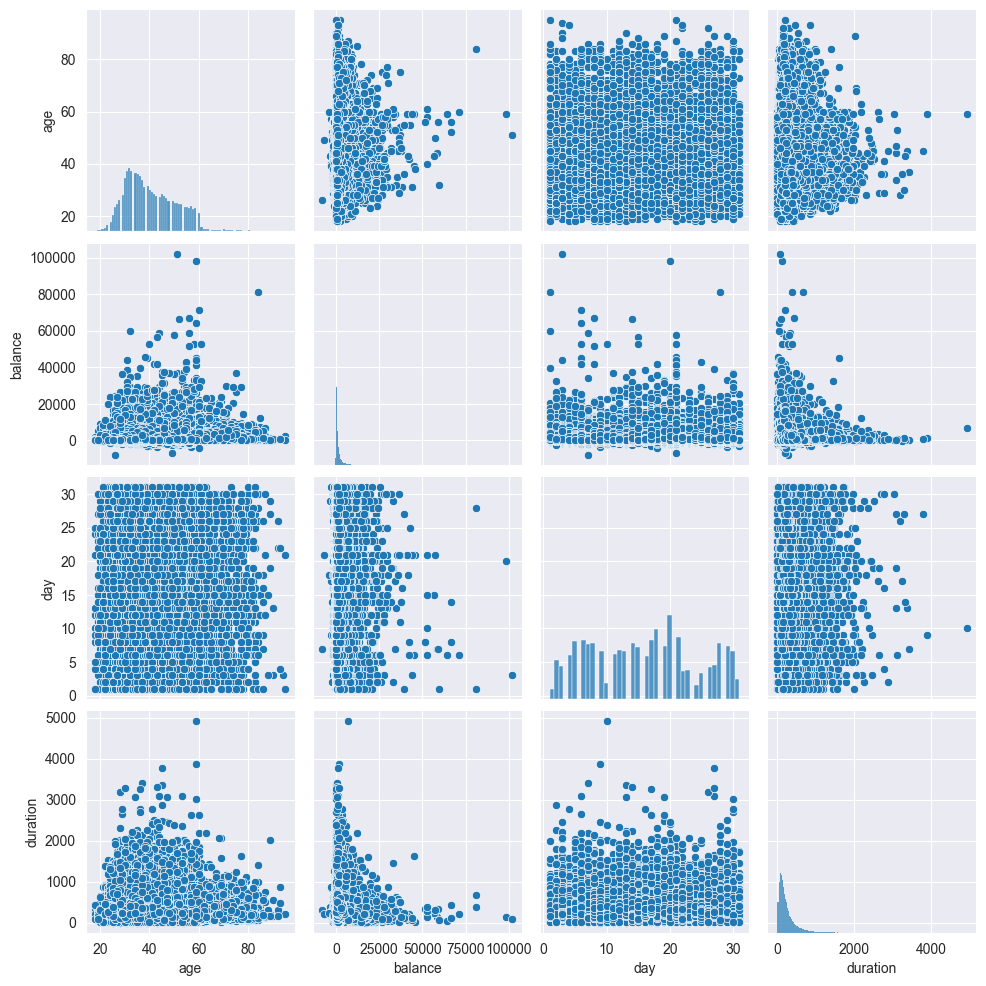

In [31]:
# plot correlations between the first 4 numerical featrues
sns.pairplot(df[numerical_vals[:4]])
plt.show()

One, final thing to do here is to check the actual values of the categorical variables in our dataset. We can easily do this with the following few lines of code:

In [32]:
# first extract the categorical variables
cat_variables = set(df.columns)-set(numerical_vals)
# print the unique values for each cat variable
for i in cat_variables:
    print('Feature [',i, '] has unique values:',df[i].unique())

Feature [ loan ] has unique values: ['no' 'yes']
Feature [ poutcome ] has unique values: ['unknown' 'failure' 'other' 'success']
Feature [ contact ] has unique values: ['unknown' 'cellular' 'telephone']
Feature [ default ] has unique values: ['no' 'yes']
Feature [ education ] has unique values: ['tertiary' 'secondary' 'unknown' 'primary']
Feature [ y ] has unique values: ['no' 'yes']
Feature [ job ] has unique values: ['management' 'technician' 'entrepreneur' 'blue-collar' 'unknown'
 'retired' 'admin.' 'services' 'self-employed' 'unemployed' 'housemaid'
 'student']
Feature [ month ] has unique values: ['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr' 'sep']
Feature [ housing ] has unique values: ['yes' 'no']
Feature [ marital ] has unique values: ['married' 'single' 'divorced']


Clearly, the above categorical variables need to be encoded to integers before we can feed it into a machine learning algorithm.

## 1.3 Data Preparation

### 1.3.1 Testing Set

Scikit-Learn is very powerful library. It provides functions to split the dataset into subsets. The
simplest function is the train_test_split(). It is used with few parameters including random_
state (to allow you to set a seed to reproduce results) and the test_size which allows you
to decide the portion of data that will be kept for testing. Often, the testing set size varies between 20 to 30% of the original data.

First, let's split our data into input features and label, then we will split it into training and
testing sets

In [33]:
# store all rows and columns apart from last column(label) in X
X = df.iloc[:,:(df.shape[1]-1)]
y = df['y']

Check the datatype of X and y above, if you are not sure. Now, let's split the dataset into
train and testing set

In [34]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=.20,random_state=15)

Notice that the splitting function above does random sampling, which could be generally acceptable
for many datasets. However, in some specific situations, you might want to do sampling with
stratifications. For example, you may want to ensure that the ratio of men to women instances are
maintained in the training and testing set, or perhaps you want to maintain certain age distribution in your training and testing sets, and so on. To achieve this sampling with stratification, you can use the StratifiedShuffleSplit() function.

In [36]:
# stratify sampling on the y attribute
from sklearn.model_selection import StratifiedShuffleSplit
split = StratifiedShuffleSplit(n_splits=1, test_size=.20,random_state=15)
for train_index, test_index in split.split(df,df['y']):
    train_set = df.loc[train_index]
    test_set = df.loc[test_index]

For this tutorial, we will just continue with the random sampling we did earlier. In other
words, we will use the X, y, X_train, X_test, and y_train and y_test for the remaining parts
of this tutorial.

One more thing worth checking when you split the data, is to see if the class distribution in
both training and testing set is well presented, which is the case as can be seen below

In [37]:
y_train.value_counts(normalize=True)

y
no     0.882216
yes    0.117784
Name: proportion, dtype: float64

In [38]:
y_test.value_counts(normalize=True)

y
no     0.88621
yes    0.11379
Name: proportion, dtype: float64

### 1.3.2 Missing Values

Our data has no missing values, therefore we don’t need to do anything regarding this task. However, in case of missing values, we can use the Scikit-Learn SimpleImputer class, as we did in
pervious weeks.


### 1.3.3 Drop Features

In almost all machine learning algorithms, you need to do something with features that have too
many missing values (i.e. more than 50% of the values are missing), and similarly, you have to
consider highly correlated features. It is better not to have a highly correlated features in the
dataset. Therefore, it is always good idea to drop a highly correlated feature with others (worst
case scenario, this will spead up computation), as well as any feature/ column that has lots of
missing values. In our dataset, we don’t have any of the above problems. But if this was the case,
then we can simply drop any feature/ column in the dataset using df.dropna() to drop features
with lots of missing values and df.drop("x",axis=1) to drop a certain feature or column from the
dataset.

### 1.3.4 Scikit-Learn Interface
For the past few weeks, we have been using the Scikit-Learn library. You have already noticed,
that this library has consistent functions that are easy to use across wide range of machine learning algorithms. Therefore, it might be useful to recall these key components of the library. The main components of the library can be outlined as follows:

- Estimators: estimators are performed using the fit() method which takes a dataset as a parameter,
example includes SimpleImputer

- Transformers: Are estimators that can transform the dataset (e.g. imputer), often make use
of the transform() method, that takes the dataset to be transformed as a parameter. All transformers have a method called fit_transform() that is equivalent to calling fit() then transform()

- Predictors: Some estimators are capable of performing predictions as we saw in the past few
weeks. Examples include LinearRegression model. Predictors have the predict() method that
takes a dataset and predict its labels (response variable)

### 1.3.5 Categorical Attributes
Recall, that our dataset has several categorical attributes (not numerical). These needs to be handled before fitting our machine leaning algorithm. See, previous sections, we stored the names of these categorical variables in a set called cat_variables

In [39]:
cat_variables

{'contact',
 'default',
 'education',
 'housing',
 'job',
 'loan',
 'marital',
 'month',
 'poutcome',
 'y'}

You can explore each of the above attributes, and see its values as we did above

In [40]:
#print the unique values for each cat variable
for i in cat_variables:
    print('Feature [',i, '] has unique values:',df[i].unique())

Feature [ loan ] has unique values: ['no' 'yes']
Feature [ poutcome ] has unique values: ['unknown' 'failure' 'other' 'success']
Feature [ contact ] has unique values: ['unknown' 'cellular' 'telephone']
Feature [ default ] has unique values: ['no' 'yes']
Feature [ education ] has unique values: ['tertiary' 'secondary' 'unknown' 'primary']
Feature [ y ] has unique values: ['no' 'yes']
Feature [ job ] has unique values: ['management' 'technician' 'entrepreneur' 'blue-collar' 'unknown'
 'retired' 'admin.' 'services' 'self-employed' 'unemployed' 'housemaid'
 'student']
Feature [ month ] has unique values: ['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr' 'sep']
Feature [ housing ] has unique values: ['yes' 'no']
Feature [ marital ] has unique values: ['married' 'single' 'divorced']


Handling these attributes is achieved by transforming these categorical values (text) into
integers. In the Scikit-Learn library, this can be achieved by either OrdinalEncoder, OneHotEncoder, or by even creating your own dummy variables. Using OrdinalEncoder is encouraged,
when dealing with ordered categories such as Excellent, Very Good, Good, and Bad,
here we can transform this into 5,4,3, 2 and 1. In our dataset, categories are not ordinal, and
so OneHotEncoder would be more appropriate choice:

**OneHotEncoder**: It creates one binary feature (column) for each category, and sets the value
to 1 when for example the category is ‘male’ and 0 when its female, or vice versa, and so on.
Lets take an example with our dataset:

In [41]:
from sklearn.preprocessing import OneHotEncoder
cat_encoder = OneHotEncoder()# instantiate a class
# code the feature called default which takes yes, no value
default_cat = df[['default']]
# encode the feature using one hot
default_one_hot = cat_encoder.fit_transform(default_cat)
default_one_hot

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 45211 stored elements and shape (45211, 2)>

The output of the above encoding is a Scipy sparse matrix. This is very useful specially if
you are working with high dimensional dataset with features of thousands of categories.
However, for our dataset, we can convert the output into numpy array as follows:

In [42]:
default_one_hot.toarray()

array([[1., 0.],
       [1., 0.],
       [1., 0.],
       ...,
       [1., 0.],
       [1., 0.],
       [1., 0.]])

If you want to get the list of categories in your vector, then simply call

In [43]:
cat_encoder.categories_

[array(['no', 'yes'], dtype=object)]

Same one hot encoding above, can be applied across all categorical variables using the pandas
get_dummies() function as follows:

In [44]:
#replace all cat variables with integers
df_encoded = pd.get_dummies(df, columns=[
'contact','default','job','education',
'housing','loan','marital',
'month','poutcome'
])

In [45]:
# check first five rows and last 4 columns
df_encoded.iloc[:5,-4:]

,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
0,False,False,False,True
1,False,False,False,True
2,False,False,False,True
3,False,False,False,True
4,False,False,False,True


You should note now that a column that has two categories e.g. yes/no, will be converted into
two columns in the dataset as can be seen above.

In [46]:
# OK, lets create a function to encode features in our dataset (X_train, X_test, y_train,y_test)
def encode_variables():
    # encode X_train
    X_train_e = pd.get_dummies(X_train, columns=[
                    'contact','default','job','education',
                    'housing','loan','marital',
                    'month','poutcome'
                ])
    # encode Y_train
    X_test_e = pd.get_dummies(X_test, columns=[
                'contact','default','job','education',
                'housing','loan','marital',
                'month','poutcome'
            ])
    # encode class labels
    y_train.replace('no',0,inplace=True)
    y_train.replace('yes',1,inplace=True)
    y_test.replace('no',0,inplace=True)
    y_test.replace('yes',1,inplace=True)
    return X_train_e, X_test_e
# now call the function above to encode all categorical variables including labels
X_train, X_test = encode_variables()

C:\Users\PJ8227\AppData\Local\Temp\ipykernel_36344\3623089714.py:17: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_train.replace('yes',1,inplace=True)
C:\Users\PJ8227\AppData\Local\Temp\ipykernel_36344\3623089714.py:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_test.replace('yes',1,inplace=True)


Now you should have fully encoded testing/ training set and labels represented by 0/ 1
values instead of yes/no. So issuing the info() function below will show all variables are
of numeric type

In [47]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 36168 entries, 6379 to 7624
Data columns (total 51 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   age                  36168 non-null  int64
 1   balance              36168 non-null  int64
 2   day                  36168 non-null  int64
 3   duration             36168 non-null  int64
 4   campaign             36168 non-null  int64
 5   pdays                36168 non-null  int64
 6   previous             36168 non-null  int64
 7   contact_cellular     36168 non-null  bool 
 8   contact_telephone    36168 non-null  bool 
 9   contact_unknown      36168 non-null  bool 
 10  default_no           36168 non-null  bool 
 11  default_yes          36168 non-null  bool 
 12  job_admin.           36168 non-null  bool 
 13  job_blue-collar      36168 non-null  bool 
 14  job_entrepreneur     36168 non-null  bool 
 15  job_housemaid        36168 non-null  bool 
 16  job_management       3616

You should notice here, that we pre-processed the data after splitting it. Of course, we could have
encoded all the categorical variables in the original data frame, then split the data. This often won’t make a difference. For other situations, such as features scaling, as we will see below, scaling the features before or after splitting the data into train/ test sets is not the same.

### 1.3.6 Features Scaling
As was shown in the exploratory of the dataset above, the features in our dataset (attributes/
columns) have different range of values. Machine Learning algorithms don’t perform well when
the input features are of very different scales (e.g. age between 20 and 60, while salary between
3000 to 20000). In our dataset, you can see that age, balance, day, duration and other numerical
features are of varying scales. There are two common approaches to handle this problem and get
all variables to the same scales:

**Min-Max Approach** This is widely known as normalisation. Basically, it shifts and rescale the
values so that they all range between 0 and 1. This formula for doing this normalisation is expressed as
 `xmin(x) / (max(x) 􀀀 min(x))`

Let's create a small subset from our dataset to show how can we use feature scaling

In [48]:
small_df = df[['age','balance','previous']]
small_df.head()

,age,balance,previous
0,58,2143,0
1,44,29,0
2,33,2,0
3,47,1506,0
4,33,1,0


Let's create a function that does the min-max features scaling. First, we will create our own
function, then we will see how we can use the scikit-learn to perform the same task:

In [49]:
# function to do min-max normalisation
def normalise(x):
    return (x -min(x))/(max(x)-min(x))

# create a copy of the small data frame (to be normalised)
small_df_n = small_df.copy(deep=True)
# scall features in the small_df_n
small_df_n[small_df_n.columns]=small_df_n[small_df_n.columns].apply(lambda x: normalise(x)).copy(deep=True)

In [50]:
small_df_n.head()

,age,balance,previous
0,0.519481,0.092259,0.0
1,0.337662,0.073067,0.0
2,0.194805,0.072822,0.0
3,0.376623,0.086476,0.0
4,0.194805,0.072812,0.0


In [51]:
# notice all columns now in one scale 0 to 1
small_df_n.describe()

,age,balance,previous
count,45211.000000,45211.000000,45211.000000
mean,0.297873,0.085171,0.002110
std,0.137906,0.027643,0.008376
min,0.000000,0.000000,0.000000
25%,0.194805,0.073457,0.000000
50%,0.272727,0.076871,0.000000
75%,0.389610,0.085768,0.000000
max,1.000000,1.000000,1.000000


The above steps, can also be replaced using the Scikit-Learn library as follows:

In [52]:
from sklearn import preprocessing
x = small_df.values #returns a numpy array
normaliser = preprocessing.MinMaxScaler()
x_scaled = normaliser.fit_transform(x)
small_df_n1 = pd.DataFrame(x_scaled)

In [53]:
small_df_n1.describe()

,0,1,2
count,45211.000000,45211.000000,45211.000000
mean,0.297873,0.085171,0.002110
std,0.137906,0.027643,0.008376
min,0.000000,0.000000,0.000000
25%,0.194805,0.073457,0.000000
50%,0.272727,0.076871,0.000000
75%,0.389610,0.085768,0.000000
max,1.000000,1.000000,1.000000


You should see that the values in the small_df_n1 are exactly the same values at the small_df_n,
and both range between 0 and 1


**Standardisation** Is another approach to scale features. It simply subtracts the mean value, and
then it divides by the standard deviation so that the resulting distribution has 1 unit variance and zero mean. This can be easily achieved using the following line of code

In [54]:
normalised_df=(small_df-small_df.mean())/small_df.std()

Notice, that now all variables have a mean value of almost zero, and 1 unit of standard
deviation.

In [55]:
normalised_df.describe()

,age,balance,previous
count,4.521100e+04,4.521100e+04,45211.000000
mean,2.011667e-16,1.760208e-17,0.000000
std,1.000000e+00,1.000000e+00,1.000000
min,-2.159970e+00,-3.081114e+00,-0.251938
25%,-7.473762e-01,-4.237673e-01,-0.251938
50%,-1.823386e-01,-3.002766e-01,-0.251938
75%,6.652178e-01,2.158719e-02,-0.251938
max,5.091346e+00,3.309441e+01,119.134665


It has to be noted that although you could use either normalisation or standardisation for
scaling features. For some applications such as Neural Networks, normalisations might be a
better choice, especially that as you saw standardisation doesn’t ensure that all values range
between 0 and 1 after the features scaling.

Scikit-Learn also provides a function to perform features standardisation called StandardScaler, a
transformer. So lets use it to scale the features in our training and testing sets

In [56]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
# transform data
scaled = scaler.fit_transform(X_train)

In [57]:
# store the data into dataframe called X_trains
X_train_s = pd.DataFrame(scaled, columns=X_train.columns)

In [58]:
# scale the testing set
scaler = StandardScaler()
# transform data
scaled = scaler.fit_transform(X_test)

In [59]:
# store the data into dataframe called X_test_s
X_test_s = pd.DataFrame(scaled, columns=X_test.columns)

Now, all the features in the dataset are scaled to have one unit variance and zero mean. It should
be noted that you could have also fit the machine learning algorithms without scaling the features,
however, this step is very desirable, and often improve performance.

## 1.4 Select and Build a Model
OK, so now we are ready to create and train our machine learning algorithm. So perhaps, we can
start by using logistic regression (See week 2 for more details about this algorithm, or check the
[Scikit-Learn Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) for more details)

On more thing to notice, often we can load, pre-processing and model the data using
make_pipeline See [This Tutorial](https://machinelearningmastery.com/columntransformer-for-numerical-and-categorical-data/) for more details. However, here, I am explaining it step by step to help you understand the basic concepts

### 1.4.1 Logistic Regression

In [60]:
from sklearn.linear_model import LogisticRegression
# create and train the model
# notice the class_weight parameter
ml_reg = LogisticRegression(solver='lbfgs',class_weight='balanced',max_iter=4000)
ml_reg.fit(X_train_s,y_train)

LogisticRegression(class_weight='balanced', max_iter=4000)

In [61]:
# make predictions
y_preds = ml_reg.predict(X_test_s)

Lets evaluate our model, first using accuracy as follows:

In [62]:
from sklearn.metrics import accuracy_score
print ('Accuracy is ',accuracy_score(y_test,y_preds))

Accuracy is  0.8404290611522724


In [63]:
# Recall that majority of the data is with label 'no', imbalanced dataset, so let's consider other metrics
from sklearn.metrics import classification_report
print(classification_report(y_test,y_preds))

              precision    recall  f1-score   support

           0       0.97      0.85      0.90      8014
           1       0.40      0.80      0.53      1029

    accuracy                           0.84      9043
   macro avg       0.68      0.82      0.72      9043
weighted avg       0.91      0.84      0.86      9043



Notice, that the precision and recall for the class 1 (‘yes’) is relatively poor compared to the instances belonging to class 0 (‘no’), clearly this is due to the imbalance problem. Our model learns to better classify the ‘no’ instances, because they are dominating the dataset. Remember that precision is expressed as follows:

precision = TP / (TP + FP)

While recall is defined as:
recall = TP / (TP + FN)

And F1 is defined as:
F1 = 2 * (precision * recall) / (precision + recall)

Notice also that according to the above two equations, low precision means low True positives,
and high false positives (i.e. customers who didn’t subscribed were incorrectly classified as ‘yes’
or 1), while low recall means that false negatives are high (customers who did subscribe, where
incorrectly classified as 0 instead of 1). Lets create a dataframe and store both actual labels and
predicted labels in it (just for further verification of results) (see week 3 for further explanation).

This is not required step, but I am putting it here to further help you understand the concepts of
false positives/ negatives and the metrics presented above:

In [64]:
# dictionary
dict_df = {
'Actual':y_test,
'Predictions':y_preds,
'Correct':0
}
results = pd.DataFrame(dict_df)
results.head()

,Actual,Predictions,Correct
41810,0,1,0
27628,0,0,0
9368,0,0,0
35436,0,0,0
43574,1,1,0


In [65]:
# get false positives
FP = results[(results.Actual==0) & (results.Predictions==1)].shape[0]
FN = results[(results.Actual==1) & (results.Predictions==0)].shape[0]
TP = results[(results.Actual==1) & (results.Predictions==1)].shape[0]
TN = results[(results.Actual==0) & (results.Predictions==0)].shape[0]

In [66]:
precision = TP/(TP+FN)
recall = TP/(TP+FP)
print(f'recall is {precision}')
print(f'precision is {recall}')

recall is 0.7988338192419825
precision is 0.39941690962099125


Notice that the above numbers are similar to the ones obtained by sklearn classification_report
function. One useful techniques to compare and evaluate different models is called the ROC
curve: * As can be seen below, values in x-axis denotes false positive rates, so lower values means
lower false positives rates and higher true negatives. * Similarly, the values on the y-axis represent the true positive rates, higher y values mean higher true positive rates and lower false negatives.

One of the metrics used is the Area Under the Curve (AUC), a prefect classifier would have an
AUC = 1

So, how we can plot this curve in Python to inspect our model above?

In [67]:
# import required libraries
from sklearn.metrics import roc_curve
# get false positive rates, true positive rates, for various thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_preds)

C:\Users\PJ8227\AppData\Local\Temp\ipykernel_36344\4181820739.py:5: MatplotlibDeprecationWarning: Passing label as a length 2 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.plot([0,1],[0,1],'b:',label=['Random','Logistic Regression'])


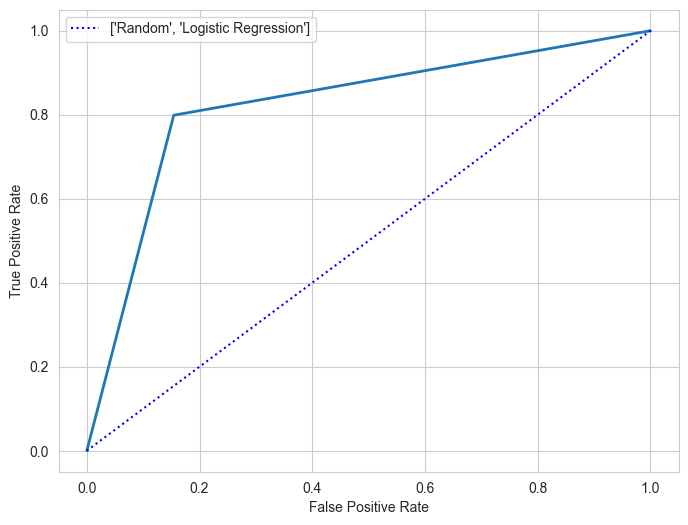

In [68]:
#plot the roc curve
sns.set_style('whitegrid')
fig = plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, linewidth=2)
plt.plot([0,1],[0,1],'b:',label=['Random','Logistic Regression'])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

It should be noted that the higher the curve pushes toward the top-left corner, then the better your model is. Clearly, our model is not performing well. So, we can do some parameters tuning as we did in previous weeks, you can also try different learning algorithms.

You can also make use of scikitplot to produce similar ROC curve, this might be more useful, as
it shows the curve for various classes in your dataset. Minor version changes have caused this code to break - if you can fix it, you can run it, otherwise the above code is your alternative.

In [75]:
#!pip install scikit-plot
#!pip install scipy==1.11.4
#import scikitplot as skplt
#y_probas = ml_reg.predict_proba(X_test_s)
#fig = skplt.metrics.plot_roc(y_test, y_probas)
#plt.show()

### 1.4.2 Create and Evaluate Diffrent Models
Recall, that we have learnt about decision trees, random forests, and support vector machines in
the past few weeks. So, how about if we create instances for some of these models, and fit your
data, to see which model produces the best results?

In [76]:
# libraries for the various models we will be using
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, roc_auc_score
# Instantiate the classfiers and make a list
# notice the parameters for each classifie
classifiers = [LogisticRegression(solver='lbfgs',max_iter=4000,class_weight='balanced'),
DecisionTreeClassifier(random_state=15),
RandomForestClassifier(n_estimators=500,random_state=15)
]

Notice how we sliced the resulting array from the function predict_proba(), for more information
on array slicing, see this [Tutorial](https://jakevdp.github.io/PythonDataScienceHandbook/02.02-the-basics-of-numpy-arrays.html)

In [ ]:
# Data frames don't like append, but lists do
# List of dictionaries is then later turned into a dataframe.
results_lst = []
# Train the models and store the results
for cls in classifiers:
    # fit the data
    model = cls.fit(X_train_s, y_train)
    # get predictions as probabilities
    # notice that predict_proba returns array (n_samples, n_classes)
    yproba = model.predict_proba(X_test_s)[::,1]
    fpr, tpr, thres = roc_curve(y_test, yproba)
    # get the auc (area under the curve)
    auc = roc_auc_score(y_test, yproba)
    # add results to the table
    results_lst.append({'classifiers':cls.__class__.__name__,
    'fpr':fpr,
    'tpr':tpr,
    'auc':auc})
# Set name of the classifiers as index labels
results_df = pd.DataFrame(results_lst)
results_df.set_index('classifiers', inplace=True)

In [90]:
display(results_df)

,fpr,tpr,auc
classifiers,,,
LogisticRegression,"[0.0, 0.00012478163214374845, 0.00037434489643...","[0.0, 0.0, 0.0, 0.0029154518950437317, 0.00291...",0.903530
DecisionTreeClassifier,"[0.0, 0.0723733466433741, 1.0]","[0.0, 0.4800777453838678, 1.0]",0.703852
RandomForestClassifier,"[0.0, 0.0, 0.0, 0.0002495632642874969, 0.00024...","[0.0, 0.0009718172983479105, 0.003887269193391...",0.928601


Now, that we trained our models, and stored results of their performances, lets plot the ROC curves for all three models.

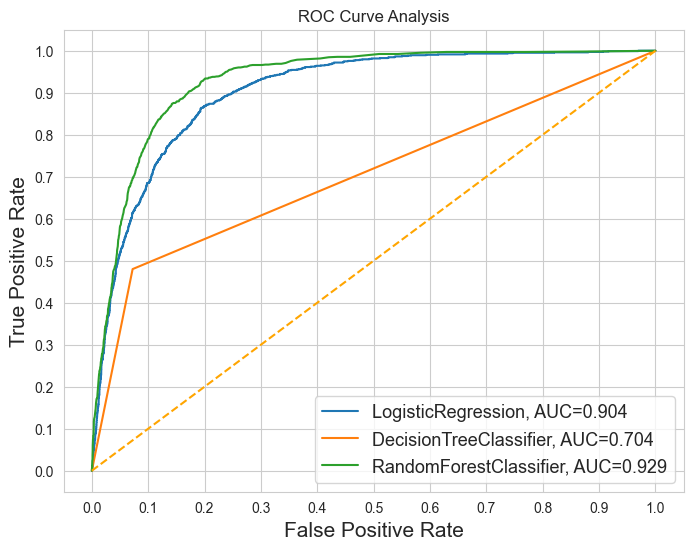

In [94]:
fig = plt.figure(figsize=(8,6))
for i in results_df.index:
    plt.plot(results_df.loc[i]['fpr'],
            results_df.loc[i]['tpr'],
            label="{}, AUC={:.3f}".format(i, results_df.loc[i]['auc']))
    
# plot the random model (diagonal)
plt.plot([0,1], [0,1], color='orange', linestyle='--')
plt.xticks(np.arange(0.0, 1.1, step=0.1))
plt.xlabel("False Positive Rate", fontsize=15)
plt.yticks(np.arange(0.0, 1.1, step=0.1))
plt.ylabel("True Positive Rate", fontsize=15)
plt.title('ROC Curve Analysis', fontsize=12)
plt.legend(prop={'size':13}, loc='lower right')
plt.show()

According to the above ROC curve, clearly Random Forests is producing the best results. However,
notice that the dataset has a class-imbalance problem. The technical details of this problem
is beyond the scope of this lab, but it should be sufficient to know the following terminologies
for now:

- Oversampling: One way to handle this problem is oversample the minority class instances
in our dataset. In our case, this means create more samples that represent the ‘yes’ clients.
Various methods are available to do so, i.e. SMOTE, Random Oversampling and others.

- Undersampling: The alternative is to undersample the majority class instances. Typically,
this means randomly removing some samples from the dataset where the client has a label
‘no’, aiming at creating more balanced dataset. Again, there are wide range of methods for
undersampling, the simplest, is just to randomly undersample the dataset. More details and
for complete example, see [this Tutorial](https://machinelearningmastery.com/random-oversampling-and-undersampling-for-imbalanced-classification/)


## 1.5 The Complete Example

It should be noted that the above detailed explanation regarding preparing and creating your
models can be achieved in so many several ways in Python. Below is a complete code that loads,
splits, pre-process, create a model (Random Forest) and show the results.

- Check the code carefully
- Try to improve performance by changing the parameters of random forests, or using grid
search to fine-tune the parameters

In [95]:
# import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from numpy import mean
from numpy import std
from numpy import absolute
from pandas import read_csv
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

In [96]:
# Load the data
df = pd.read_csv('bank-full.csv',sep=';')

In [97]:
# store all rows and columns apart from last column(label) in X
X = df.iloc[:,:(df.shape[1]-1)]
y = df['y']

In [99]:
# split the data into train and test
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=.20,random_state=15)
# lets check the shapes of train/test sets
print(X_train.shape, X_test.shape)

(36168, 16) (9043, 16)


Here, we can check the types of variables available in our dataset. This should give you a
list of categorical variables as well as the numerical variables

In [100]:
# Numerical and categorical values
num_vars = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_vars = X_train.select_dtypes(include=['object', 'bool']).columns
print('Numerical Vars are ',num_vars)
print('Categorical vars are ',cat_vars)

Numerical Vars are  Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')
Categorical vars are  Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='object')


Recall, that we need to scale the features in our dataset, as well as encode all the categorical
variables. We will use OneHotEncoder for the categorical variables and MinMaxScaler for the
numerical variables

In [101]:
# data pre-processing: OneHotEncoder (for categorical variables)
# MinMax Scaler for numerical variables
pre_process = [('cat', OneHotEncoder(), cat_vars), ('num', MinMaxScaler(), num_vars)]
# use ColumnTransformer to apply the above pre-processing to the desired columns
cols_transform = ColumnTransformer(transformers=pre_process)

Let's create our RandomForestClassifier

In [102]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(random_state=15,
n_estimators=500,
max_features='sqrt',
)

Let's create our pipeline, use 10-fold cross validation and grid search to search for the best
parameters in for Random Forest Classifier

In [103]:
# add pre-processing, model in one pipeline
rf_pipeline = Pipeline(steps=[('prep',cols_transform), ('m', model)])

In [104]:
# encode the class labels
y_train.replace('no',0,inplace=True)
y_train.replace('yes',1,inplace=True)
y_test.replace('no',0,inplace=True)
y_test.replace('yes',1,inplace=True)

C:\Users\PJ8227\AppData\Local\Temp\ipykernel_36344\1843012885.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_train.replace('yes',1,inplace=True)
C:\Users\PJ8227\AppData\Local\Temp\ipykernel_36344\1843012885.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_test.replace('yes',1,inplace=True)


Train the model on the training set

In [ ]:
# train the model might take a while!
rf_train = rf_pipeline.fit(X_train,y_train)

Test using the testing set X_test

In [106]:
predictions = rf_pipeline.predict(X_test)
np.mean(predictions==y_test)

np.float64(0.9044564856795311)

In [107]:
probs = rf_pipeline.predict_proba(X_test)
# probs of positive classes only
probs = probs[:, 1]
# compute auc score
auc = roc_auc_score(y_test, probs)
print('AUC: %.2f' % auc)

AUC: 0.93


In [108]:
type(rf_pipeline)

sklearn.pipeline.Pipeline

In [109]:
# create a small function to plot the roc curve (same as code above)
def plot_roc_curve(fpr, tpr):
    plt.plot(fpr, tpr, color='blue', label='ROC')
    plt.plot([0, 1], [0, 1], color='red', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.show()

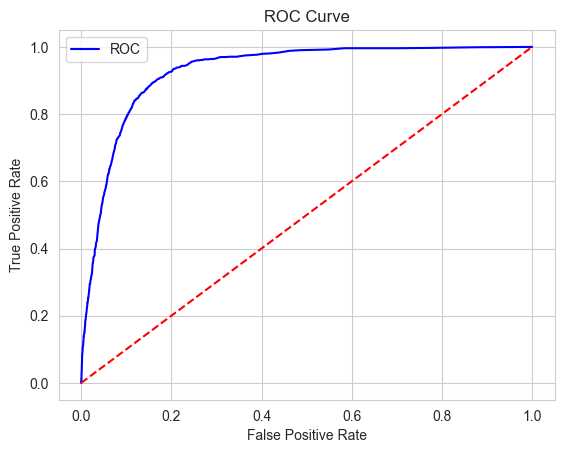

In [110]:
# Plot the roc curve
fpr, tpr, thresholds = roc_curve(y_test, probs)
plot_roc_curve(fpr, tpr)